In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input/os2391/OS2931.csv'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [3]:
import pandas as pd
import numpy as np
d=pd.read_csv("/kaggle/input/os2391/OS2931.csv")

In [4]:
print(d)

      iD                                           Response  Reviewer-1  \
0      1  An operating system (OS) is system software th...           4   
1      1  An operating system is the most important soft...           5   
2      1  Collection of programs that manages hardware r...           2   
3      1      It is an interface user and machine(hardware)           2   
4      1  An operating system is a software which acts a...           3   
...   ..                                                ...         ...   
2385   5  Single processor contains only one processer.w...           2   
2386   5  Single processor systems are less reliable tha...           3   
2387   5  Single processor system contains only one proc...           2   
2388   5  Single processor can assign only one task but ...           1   
2389   5  Single Processor\n-> Uses a single cpu\n-> Eas...           2   

      Reviewer-2  
0              4  
1              5  
2              1  
3              1  
4   

In [6]:
d.head()

,iD,Response,Reviewer-1,Reviewer-2
0,1,An operating system (OS) is system software th...,4,4
1,1,An operating system is the most important soft...,5,5
2,1,Collection of programs that manages hardware r...,2,1
3,1,It is an interface user and machine(hardware),2,1
4,1,An operating system is a software which acts a...,3,2


id==1

Using device: cuda
Original score distribution:
avg_score
1     95
2    215
3     82
4     58
5     29
Name: count, dtype: int64

Samples: 479, Classes: 5


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



🚀 Starting training...
Epoch 1/10:
  Training Loss: 1.3900
  Validation QWK: 0.1555
Epoch 2/10:
  Training Loss: 1.1609
  Validation QWK: 0.1932
Epoch 3/10:
  Training Loss: 0.9912
  Validation QWK: 0.6590
Epoch 4/10:
  Training Loss: 0.9480
  Validation QWK: 0.6335
Epoch 5/10:
  Training Loss: 0.8426
  Validation QWK: 0.7069
Epoch 6/10:
  Training Loss: 0.7385
  Validation QWK: 0.7691
Epoch 7/10:
  Training Loss: 0.6205
  Validation QWK: 0.8164
Epoch 8/10:
  Training Loss: 0.5771
  Validation QWK: 0.7957
Epoch 9/10:
  Training Loss: 0.4925
  Validation QWK: 0.8230
Epoch 10/10:
  Training Loss: 0.4631
  Validation QWK: 0.7802

🏆 Best Validation QWK: 0.8230


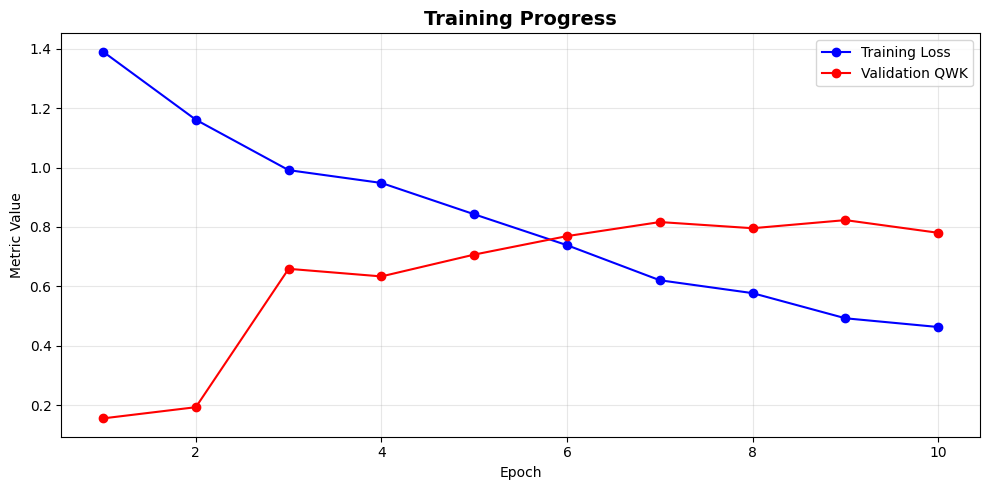


✅ Overall QWK Score on Validation: 0.7802


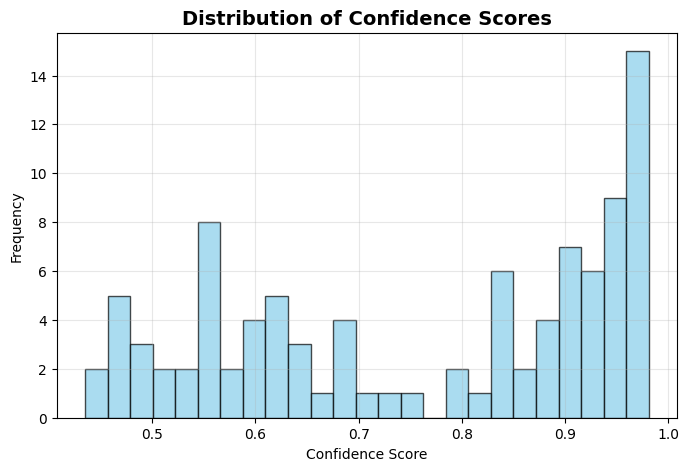


Text: Operating system manages all resources efficiently.
Predicted Score: 1, Confidence: 0.928

Text: An OS handles memory, process and file management.
Predicted Score: 2, Confidence: 0.909

Text: Operating system acts as an interface between hardware and user.
Predicted Score: 1, Confidence: 0.763


In [7]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import cohen_kappa_score
import matplotlib.pyplot as plt
from torch.nn.functional import softmax
import warnings
warnings.filterwarnings('ignore')

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ========================
#  QWK METRIC
# ========================
def quadratic_weighted_kappa(y_true, y_pred, labels=None):
    """Calculate Quadratic Weighted Kappa (QWK) score"""
    return cohen_kappa_score(y_true, y_pred, labels=labels, weights='quadratic')


# ========================
#  DATASET
# ========================
class EssayDataset(Dataset):
    def __init__(self, texts, scores, tokenizer, max_length=512):
        self.texts = texts
        self.scores = scores
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        score = self.scores[idx]

        encoding = self.tokenizer.encode_plus(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_attention_mask=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(score, dtype=torch.long)
        }


# ========================
#  TRAINING LOOP
# ========================
def train_model(model, train_loader, val_loader, num_epochs=5, learning_rate=2e-5):
    optimizer = AdamW(model.parameters(), lr=learning_rate)
    criterion = nn.CrossEntropyLoss()

    best_qwk = 0
    train_losses, val_qwk_scores, epochs_list = [], [], []

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0

        for batch in train_loader:
            optimizer.zero_grad()
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # ===== Validation =====
        model.eval()
        val_predictions, val_true_labels = [], []
        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)

                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                predictions = torch.argmax(outputs.logits, dim=-1)

                val_predictions.extend(predictions.cpu().numpy())
                val_true_labels.extend(labels.cpu().numpy())

        # Compute QWK
        qwk_score = quadratic_weighted_kappa(val_true_labels, val_predictions)
        val_qwk_scores.append(qwk_score)
        epochs_list.append(epoch + 1)

        print(f"Epoch {epoch+1}/{num_epochs}:")
        print(f"  Training Loss: {avg_train_loss:.4f}")
        print(f"  Validation QWK: {qwk_score:.4f}")

        # Save best model
        if qwk_score > best_qwk:
            best_qwk = qwk_score
            torch.save(model.state_dict(), 'best_bert_model.pth')

    return best_qwk, train_losses, val_qwk_scores, epochs_list


# ========================
#  TRAINING PLOTS
# ========================
def plot_training_metrics(train_losses, val_qwk_scores, epochs_list):
    plt.figure(figsize=(10, 5))
    plt.plot(epochs_list, train_losses, 'b-o', label='Training Loss')
    plt.plot(epochs_list, val_qwk_scores, 'r-o', label='Validation QWK')
    plt.title("Training Progress", fontsize=14, fontweight="bold")
    plt.xlabel("Epoch")
    plt.ylabel("Metric Value")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


# ========================
#  PREDICTION WITH CONFIDENCE
# ========================
def predict_scores_with_confidence(model, tokenizer, texts):
    model.eval()
    predictions, confidence_scores, all_probabilities = [], [], []

    with torch.no_grad():
        for text in texts:
            encoding = tokenizer.encode_plus(
                str(text),
                truncation=True,
                padding='max_length',
                max_length=512,
                return_attention_mask=True,
                return_tensors='pt'
            )

            input_ids = encoding['input_ids'].to(device)
            attention_mask = encoding['attention_mask'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)

            probs = softmax(outputs.logits, dim=-1)
            pred = torch.argmax(probs, dim=-1)
            conf = torch.max(probs).item()

            predictions.append(pred.cpu().numpy()[0] + 1)
            confidence_scores.append(conf)
            all_probabilities.append(probs.cpu().numpy()[0])

    return predictions, confidence_scores, all_probabilities


# ========================
#  VALIDATION CONFIDENCE ANALYSIS (QWK ONLY)
# ========================
def get_validation_confidence_scores(model, val_loader):
    model.eval()
    preds, confs, labels = [], [], []

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            y = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            probs = softmax(outputs.logits, dim=-1)
            pred = torch.argmax(probs, dim=-1)
            conf = torch.max(probs, dim=-1)[0]

            preds.extend(pred.cpu().numpy())
            confs.extend(conf.cpu().numpy())
            labels.extend(y.cpu().numpy())

    qwk = quadratic_weighted_kappa(labels, preds)
    print(f"\n✅ Overall QWK Score on Validation: {qwk:.4f}")
    return preds, confs, labels


def plot_confidence_distribution(confidence_scores):
    plt.figure(figsize=(8, 5))
    plt.hist(confidence_scores, bins=25, color='skyblue', edgecolor='black', alpha=0.7)
    plt.title("Distribution of Confidence Scores", fontsize=14, fontweight="bold")
    plt.xlabel("Confidence Score")
    plt.ylabel("Frequency")
    plt.grid(alpha=0.3)
    plt.show()


# ========================
#  MAIN FUNCTION
# ========================
def main():
    # Assuming 'd' DataFrame already exists
    df_id1 = d[d['iD'] == 1].copy()
    df_id1['avg_score'] = ((df_id1['Reviewer-1'] + df_id1['Reviewer-2']) / 2).round().astype(int)
    df_id1 = df_id1[df_id1['avg_score'].between(1, 5)]

    print("Original score distribution:")
    print(df_id1['avg_score'].value_counts().sort_index())

    texts = df_id1['Response'].values
    scores = df_id1['avg_score'].values
    scores_encoded = scores - 1
    num_classes = 5

    print(f"\nSamples: {len(texts)}, Classes: {num_classes}")

    X_train, X_val, y_train, y_val = train_test_split(
        texts, scores_encoded, test_size=0.2, random_state=42, stratify=scores_encoded
    )

    tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
    model = BertForSequenceClassification.from_pretrained(
        'bert-base-uncased', num_labels=num_classes
    ).to(device)

    train_dataset = EssayDataset(X_train, y_train, tokenizer)
    val_dataset = EssayDataset(X_val, y_val, tokenizer)
    train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

    print("\n🚀 Starting training...")
    best_qwk, train_losses, val_qwk_scores, epochs_list = train_model(
        model, train_loader, val_loader, num_epochs=10
    )

    print(f"\n🏆 Best Validation QWK: {best_qwk:.4f}")
    plot_training_metrics(train_losses, val_qwk_scores, epochs_list)

    return model, tokenizer, val_loader


# ========================
#  EXECUTION
# ========================
if __name__ == "__main__":
    model, tokenizer, val_loader = main()

    preds, confs, labels = get_validation_confidence_scores(model, val_loader)
    plot_confidence_distribution(confs)

    # Example sample predictions
    sample_texts = [
        "Operating system manages all resources efficiently.",
        "An OS handles memory, process and file management.",
        "Operating system acts as an interface between hardware and user."
    ]
    preds, confs, probs = predict_scores_with_confidence(model, tokenizer, sample_texts)
    for t, p, c in zip(sample_texts, preds, confs):
        print(f"\nText: {t}\nPredicted Score: {p}, Confidence: {c:.3f}")


id==2

Using device: cuda
Original score distribution:
avg_score
1    125
2    222
3    121
4     61
5     40
Name: count, dtype: int64

Samples: 569, Classes: 5


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



🚀 Starting training...
Epoch 1/20:
  Training Loss: 1.4445
  Validation QWK: 0.1643
Epoch 2/20:
  Training Loss: 1.2042
  Validation QWK: 0.3593
Epoch 3/20:
  Training Loss: 1.0170
  Validation QWK: 0.6014
Epoch 4/20:
  Training Loss: 0.8986
  Validation QWK: 0.7304
Epoch 5/20:
  Training Loss: 0.7595
  Validation QWK: 0.7693
Epoch 6/20:
  Training Loss: 0.6542
  Validation QWK: 0.7788
Epoch 7/20:
  Training Loss: 0.5842
  Validation QWK: 0.7999
Epoch 8/20:
  Training Loss: 0.4957
  Validation QWK: 0.7950
Epoch 9/20:
  Training Loss: 0.4683
  Validation QWK: 0.7811
Epoch 10/20:
  Training Loss: 0.4198
  Validation QWK: 0.7696
Epoch 11/20:
  Training Loss: 0.3631
  Validation QWK: 0.8147
Epoch 12/20:
  Training Loss: 0.3547
  Validation QWK: 0.8025
Epoch 13/20:
  Training Loss: 0.2921
  Validation QWK: 0.7648
Epoch 14/20:
  Training Loss: 0.2894
  Validation QWK: 0.8150
Epoch 15/20:
  Training Loss: 0.3107
  Validation QWK: 0.7987
Epoch 16/20:
  Training Loss: 0.2550
  Validation QWK: 

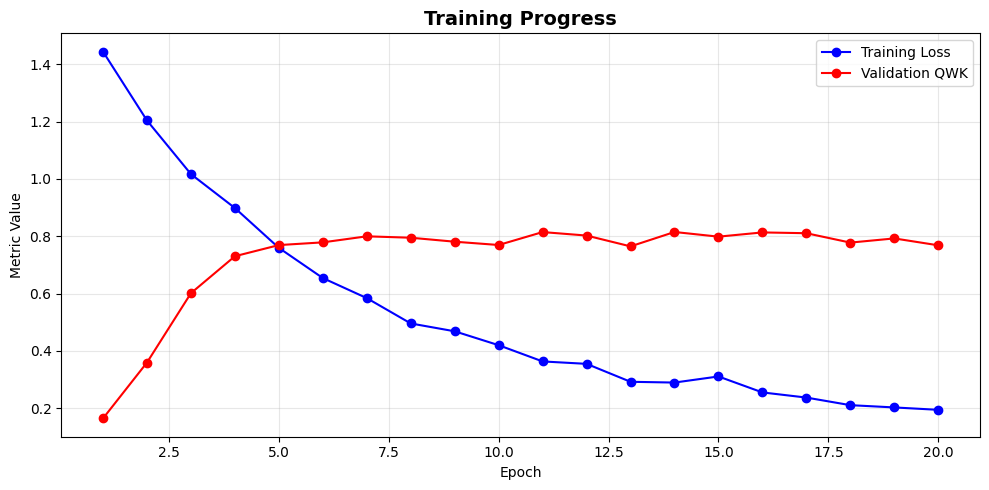


✅ Overall QWK Score on Validation: 0.7685


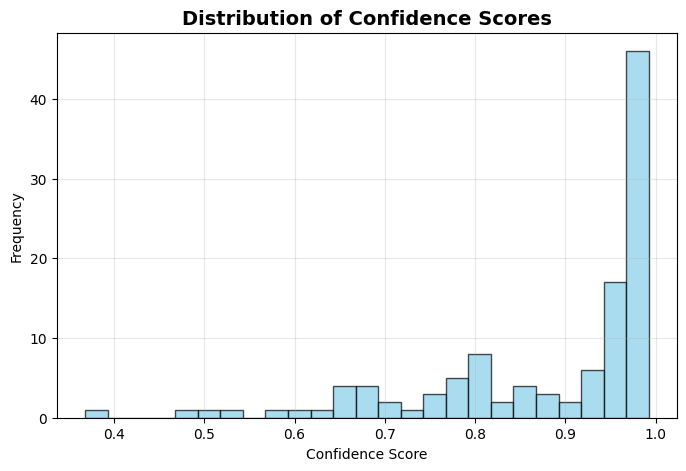


Text: Operating system manages all resources efficiently.
Predicted Score: 1, Confidence: 0.837

Text: An OS handles memory, process and file management.
Predicted Score: 1, Confidence: 0.990

Text: Operating system acts as an interface between hardware and user.
Predicted Score: 1, Confidence: 0.984


In [5]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import cohen_kappa_score
import matplotlib.pyplot as plt
from torch.nn.functional import softmax
import warnings
warnings.filterwarnings('ignore')

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ========================
#  QWK METRIC
# ========================
def quadratic_weighted_kappa(y_true, y_pred, labels=None):
    """Calculate Quadratic Weighted Kappa (QWK) score"""
    return cohen_kappa_score(y_true, y_pred, labels=labels, weights='quadratic')


# ========================
#  DATASET
# ========================
class EssayDataset(Dataset):
    def __init__(self, texts, scores, tokenizer, max_length=512):
        self.texts = texts
        self.scores = scores
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        score = self.scores[idx]

        encoding = self.tokenizer.encode_plus(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_attention_mask=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(score, dtype=torch.long)
        }


# ========================
#  TRAINING LOOP
# ========================
def train_model(model, train_loader, val_loader, num_epochs=20, learning_rate=2e-5):
    optimizer = AdamW(model.parameters(), lr=learning_rate)
    criterion = nn.CrossEntropyLoss()

    best_qwk = 0
    train_losses, val_qwk_scores, epochs_list = [], [], []

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0

        for batch in train_loader:
            optimizer.zero_grad()
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # ===== Validation =====
        model.eval()
        val_predictions, val_true_labels = [], []
        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)

                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                predictions = torch.argmax(outputs.logits, dim=-1)

                val_predictions.extend(predictions.cpu().numpy())
                val_true_labels.extend(labels.cpu().numpy())

        # Compute QWK
        qwk_score = quadratic_weighted_kappa(val_true_labels, val_predictions)
        val_qwk_scores.append(qwk_score)
        epochs_list.append(epoch + 1)

        print(f"Epoch {epoch+1}/{num_epochs}:")
        print(f"  Training Loss: {avg_train_loss:.4f}")
        print(f"  Validation QWK: {qwk_score:.4f}")

        # Save best model
        if qwk_score > best_qwk:
            best_qwk = qwk_score
            torch.save(model.state_dict(), 'best_bert_model.pth')

    return best_qwk, train_losses, val_qwk_scores, epochs_list


# ========================
#  TRAINING PLOTS
# ========================
def plot_training_metrics(train_losses, val_qwk_scores, epochs_list):
    plt.figure(figsize=(10, 5))
    plt.plot(epochs_list, train_losses, 'b-o', label='Training Loss')
    plt.plot(epochs_list, val_qwk_scores, 'r-o', label='Validation QWK')
    plt.title("Training Progress", fontsize=14, fontweight="bold")
    plt.xlabel("Epoch")
    plt.ylabel("Metric Value")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


# ========================
#  PREDICTION WITH CONFIDENCE
# ========================
def predict_scores_with_confidence(model, tokenizer, texts):
    model.eval()
    predictions, confidence_scores, all_probabilities = [], [], []

    with torch.no_grad():
        for text in texts:
            encoding = tokenizer.encode_plus(
                str(text),
                truncation=True,
                padding='max_length',
                max_length=512,
                return_attention_mask=True,
                return_tensors='pt'
            )

            input_ids = encoding['input_ids'].to(device)
            attention_mask = encoding['attention_mask'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)

            probs = softmax(outputs.logits, dim=-1)
            pred = torch.argmax(probs, dim=-1)
            conf = torch.max(probs).item()

            predictions.append(pred.cpu().numpy()[0] + 1)
            confidence_scores.append(conf)
            all_probabilities.append(probs.cpu().numpy()[0])

    return predictions, confidence_scores, all_probabilities


# ========================
#  VALIDATION CONFIDENCE ANALYSIS (QWK ONLY)
# ========================
def get_validation_confidence_scores(model, val_loader):
    model.eval()
    preds, confs, labels = [], [], []

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            y = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            probs = softmax(outputs.logits, dim=-1)
            pred = torch.argmax(probs, dim=-1)
            conf = torch.max(probs, dim=-1)[0]

            preds.extend(pred.cpu().numpy())
            confs.extend(conf.cpu().numpy())
            labels.extend(y.cpu().numpy())

    qwk = quadratic_weighted_kappa(labels, preds)
    print(f"\n✅ Overall QWK Score on Validation: {qwk:.4f}")
    return preds, confs, labels


def plot_confidence_distribution(confidence_scores):
    plt.figure(figsize=(8, 5))
    plt.hist(confidence_scores, bins=25, color='skyblue', edgecolor='black', alpha=0.7)
    plt.title("Distribution of Confidence Scores", fontsize=14, fontweight="bold")
    plt.xlabel("Confidence Score")
    plt.ylabel("Frequency")
    plt.grid(alpha=0.3)
    plt.show()


# ========================
#  MAIN FUNCTION
# ========================
def main():
    # Assuming 'd' DataFrame already exists
    df_id1 = d[d['iD'] == 2].copy()
    df_id1['avg_score'] = ((df_id1['Reviewer-1'] + df_id1['Reviewer-2']) / 2).round().astype(int)
    df_id1 = df_id1[df_id1['avg_score'].between(1, 5)]

    print("Original score distribution:")
    print(df_id1['avg_score'].value_counts().sort_index())

    texts = df_id1['Response'].values
    scores = df_id1['avg_score'].values
    scores_encoded = scores - 1
    num_classes = 5

    print(f"\nSamples: {len(texts)}, Classes: {num_classes}")

    X_train, X_val, y_train, y_val = train_test_split(
        texts, scores_encoded, test_size=0.2, random_state=42, stratify=scores_encoded
    )

    tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
    model = BertForSequenceClassification.from_pretrained(
        'bert-base-uncased', num_labels=num_classes
    ).to(device)

    train_dataset = EssayDataset(X_train, y_train, tokenizer)
    val_dataset = EssayDataset(X_val, y_val, tokenizer)
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

    print("\n🚀 Starting training...")
    best_qwk, train_losses, val_qwk_scores, epochs_list = train_model(
        model, train_loader, val_loader, num_epochs=20
    )

    print(f"\n🏆 Best Validation QWK: {best_qwk:.4f}")
    plot_training_metrics(train_losses, val_qwk_scores, epochs_list)

    return model, tokenizer, val_loader


# ========================
#  EXECUTION
# ========================
if __name__ == "__main__":
    model, tokenizer, val_loader = main()

    preds, confs, labels = get_validation_confidence_scores(model, val_loader)
    plot_confidence_distribution(confs)

    # Example sample predictions
    sample_texts = [
        "Operating system manages all resources efficiently.",
        "An OS handles memory, process and file management.",
        "Operating system acts as an interface between hardware and user."
    ]
    preds, confs, probs = predict_scores_with_confidence(model, tokenizer, sample_texts)
    for t, p, c in zip(sample_texts, preds, confs):
        print(f"\nText: {t}\nPredicted Score: {p}, Confidence: {c:.3f}")


id==3

Using device: cuda
Original score distribution:
avg_score
1    107
2    102
3     85
4      4
5      2
Name: count, dtype: int64

Samples: 300, Classes: 5


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



🚀 Starting training...
Epoch 1/10:
  Training Loss: 1.2593
  Validation QWK: 0.7644
Epoch 2/10:
  Training Loss: 0.9284
  Validation QWK: 0.7105
Epoch 3/10:
  Training Loss: 0.7806
  Validation QWK: 0.4943
Epoch 4/10:
  Training Loss: 0.6922
  Validation QWK: 0.5577
Epoch 5/10:
  Training Loss: 0.6229
  Validation QWK: 0.6224
Epoch 6/10:
  Training Loss: 0.4855
  Validation QWK: 0.7420
Epoch 7/10:
  Training Loss: 0.3924
  Validation QWK: 0.5767
Epoch 8/10:
  Training Loss: 0.3145
  Validation QWK: 0.5967
Epoch 9/10:
  Training Loss: 0.2926
  Validation QWK: 0.5703
Epoch 10/10:
  Training Loss: 0.2676
  Validation QWK: 0.6016

🏆 Best Validation QWK: 0.7644


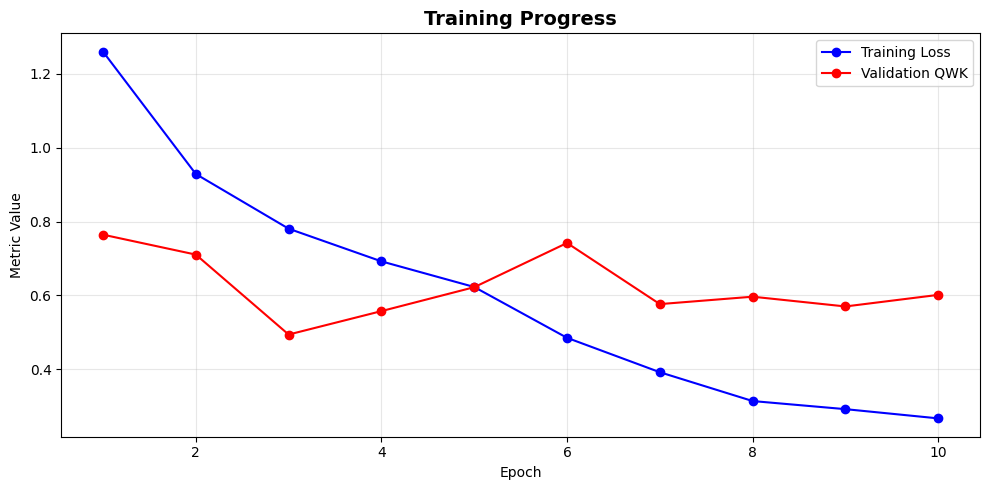


✅ Overall QWK Score on Validation: 0.6016


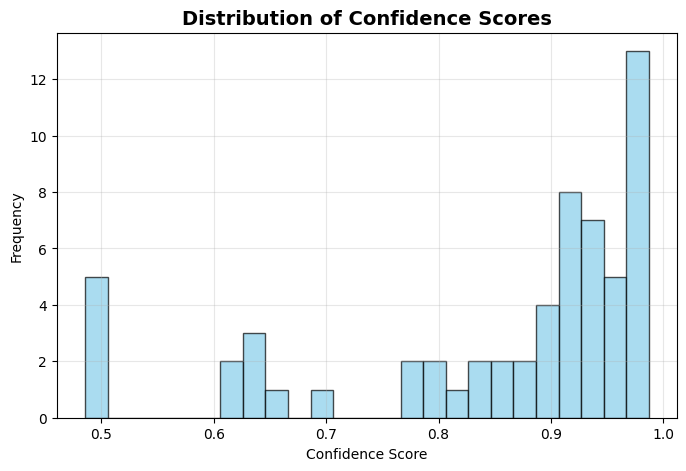


Text: Operating system manages all resources efficiently.
Predicted Score: 1, Confidence: 0.981

Text: An OS handles memory, process and file management.
Predicted Score: 1, Confidence: 0.767

Text: Operating system acts as an interface between hardware and user.
Predicted Score: 1, Confidence: 0.982


In [7]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import cohen_kappa_score
import matplotlib.pyplot as plt
from torch.nn.functional import softmax
import warnings
warnings.filterwarnings('ignore')

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ========================
#  QWK METRIC
# ========================
def quadratic_weighted_kappa(y_true, y_pred, labels=None):
    """Calculate Quadratic Weighted Kappa (QWK) score"""
    return cohen_kappa_score(y_true, y_pred, labels=labels, weights='quadratic')


# ========================
#  DATASET
# ========================
class EssayDataset(Dataset):
    def __init__(self, texts, scores, tokenizer, max_length=512):
        self.texts = texts
        self.scores = scores
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        score = self.scores[idx]

        encoding = self.tokenizer.encode_plus(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_attention_mask=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(score, dtype=torch.long)
        }


# ========================
#  TRAINING LOOP
# ========================
def train_model(model, train_loader, val_loader, num_epochs=10, learning_rate=2e-5):
    optimizer = AdamW(model.parameters(), lr=learning_rate)
    criterion = nn.CrossEntropyLoss()

    best_qwk = 0
    train_losses, val_qwk_scores, epochs_list = [], [], []

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0

        for batch in train_loader:
            optimizer.zero_grad()
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # ===== Validation =====
        model.eval()
        val_predictions, val_true_labels = [], []
        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)

                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                predictions = torch.argmax(outputs.logits, dim=-1)

                val_predictions.extend(predictions.cpu().numpy())
                val_true_labels.extend(labels.cpu().numpy())

        # Compute QWK
        qwk_score = quadratic_weighted_kappa(val_true_labels, val_predictions)
        val_qwk_scores.append(qwk_score)
        epochs_list.append(epoch + 1)

        print(f"Epoch {epoch+1}/{num_epochs}:")
        print(f"  Training Loss: {avg_train_loss:.4f}")
        print(f"  Validation QWK: {qwk_score:.4f}")

        # Save best model
        if qwk_score > best_qwk:
            best_qwk = qwk_score
            torch.save(model.state_dict(), 'best_bert_model.pth')

    return best_qwk, train_losses, val_qwk_scores, epochs_list


# ========================
#  TRAINING PLOTS
# ========================
def plot_training_metrics(train_losses, val_qwk_scores, epochs_list):
    plt.figure(figsize=(10, 5))
    plt.plot(epochs_list, train_losses, 'b-o', label='Training Loss')
    plt.plot(epochs_list, val_qwk_scores, 'r-o', label='Validation QWK')
    plt.title("Training Progress", fontsize=14, fontweight="bold")
    plt.xlabel("Epoch")
    plt.ylabel("Metric Value")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


# ========================
#  PREDICTION WITH CONFIDENCE
# ========================
def predict_scores_with_confidence(model, tokenizer, texts):
    model.eval()
    predictions, confidence_scores, all_probabilities = [], [], []

    with torch.no_grad():
        for text in texts:
            encoding = tokenizer.encode_plus(
                str(text),
                truncation=True,
                padding='max_length',
                max_length=512,
                return_attention_mask=True,
                return_tensors='pt'
            )

            input_ids = encoding['input_ids'].to(device)
            attention_mask = encoding['attention_mask'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)

            probs = softmax(outputs.logits, dim=-1)
            pred = torch.argmax(probs, dim=-1)
            conf = torch.max(probs).item()

            predictions.append(pred.cpu().numpy()[0] + 1)
            confidence_scores.append(conf)
            all_probabilities.append(probs.cpu().numpy()[0])

    return predictions, confidence_scores, all_probabilities


# ========================
#  VALIDATION CONFIDENCE ANALYSIS (QWK ONLY)
# ========================
def get_validation_confidence_scores(model, val_loader):
    model.eval()
    preds, confs, labels = [], [], []

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            y = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            probs = softmax(outputs.logits, dim=-1)
            pred = torch.argmax(probs, dim=-1)
            conf = torch.max(probs, dim=-1)[0]

            preds.extend(pred.cpu().numpy())
            confs.extend(conf.cpu().numpy())
            labels.extend(y.cpu().numpy())

    qwk = quadratic_weighted_kappa(labels, preds)
    print(f"\n✅ Overall QWK Score on Validation: {qwk:.4f}")
    return preds, confs, labels


def plot_confidence_distribution(confidence_scores):
    plt.figure(figsize=(8, 5))
    plt.hist(confidence_scores, bins=25, color='skyblue', edgecolor='black', alpha=0.7)
    plt.title("Distribution of Confidence Scores", fontsize=14, fontweight="bold")
    plt.xlabel("Confidence Score")
    plt.ylabel("Frequency")
    plt.grid(alpha=0.3)
    plt.show()


# ========================
#  MAIN FUNCTION
# ========================
def main():
    # Assuming 'd' DataFrame already exists
    df_id1 = d[d['iD'] == 3].copy()
    df_id1['avg_score'] = ((df_id1['Reviewer-1'] + df_id1['Reviewer-2']) / 2).round().astype(int)
    df_id1 = df_id1[df_id1['avg_score'].between(1, 5)]

    print("Original score distribution:")
    print(df_id1['avg_score'].value_counts().sort_index())

    texts = df_id1['Response'].values
    scores = df_id1['avg_score'].values
    scores_encoded = scores - 1
    num_classes = 5

    print(f"\nSamples: {len(texts)}, Classes: {num_classes}")

    X_train, X_val, y_train, y_val = train_test_split(
        texts, scores_encoded, test_size=0.2, random_state=42, stratify=scores_encoded
    )

    tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
    model = BertForSequenceClassification.from_pretrained(
        'bert-base-uncased', num_labels=num_classes
    ).to(device)

    train_dataset = EssayDataset(X_train, y_train, tokenizer)
    val_dataset = EssayDataset(X_val, y_val, tokenizer)
    train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

    print("\n🚀 Starting training...")
    best_qwk, train_losses, val_qwk_scores, epochs_list = train_model(
        model, train_loader, val_loader, num_epochs=10
    )

    print(f"\n🏆 Best Validation QWK: {best_qwk:.4f}")
    plot_training_metrics(train_losses, val_qwk_scores, epochs_list)

    return model, tokenizer, val_loader


# ========================
#  EXECUTION
# ========================
if __name__ == "__main__":
    model, tokenizer, val_loader = main()

    preds, confs, labels = get_validation_confidence_scores(model, val_loader)
    plot_confidence_distribution(confs)

    # Example sample predictions
    sample_texts = [
        "Operating system manages all resources efficiently.",
        "An OS handles memory, process and file management.",
        "Operating system acts as an interface between hardware and user."
    ]
    preds, confs, probs = predict_scores_with_confidence(model, tokenizer, sample_texts)
    for t, p, c in zip(sample_texts, preds, confs):
        print(f"\nText: {t}\nPredicted Score: {p}, Confidence: {c:.3f}")


id==4

Using device: cuda
Original score distribution:
avg_score
1    180
2    145
3    121
4      7
5      3
Name: count, dtype: int64

Samples: 456, Classes: 5


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



🚀 Starting training...
Epoch 1/20:
  Training Loss: 1.3284
  Validation QWK: 0.3133
Epoch 2/20:
  Training Loss: 1.1410
  Validation QWK: 0.7091
Epoch 3/20:
  Training Loss: 0.9645
  Validation QWK: 0.7691
Epoch 4/20:
  Training Loss: 0.8129
  Validation QWK: 0.8193
Epoch 5/20:
  Training Loss: 0.7252
  Validation QWK: 0.8135
Epoch 6/20:
  Training Loss: 0.6725
  Validation QWK: 0.7925
Epoch 7/20:
  Training Loss: 0.5608
  Validation QWK: 0.7910
Epoch 8/20:
  Training Loss: 0.4959
  Validation QWK: 0.8089
Epoch 9/20:
  Training Loss: 0.4237
  Validation QWK: 0.8013
Epoch 10/20:
  Training Loss: 0.3855
  Validation QWK: 0.7839
Epoch 11/20:
  Training Loss: 0.3664
  Validation QWK: 0.7494
Epoch 12/20:
  Training Loss: 0.3063
  Validation QWK: 0.7604
Epoch 13/20:
  Training Loss: 0.2935
  Validation QWK: 0.7540
Epoch 14/20:
  Training Loss: 0.2887
  Validation QWK: 0.7570
Epoch 15/20:
  Training Loss: 0.2446
  Validation QWK: 0.7490
Epoch 16/20:
  Training Loss: 0.2427
  Validation QWK: 

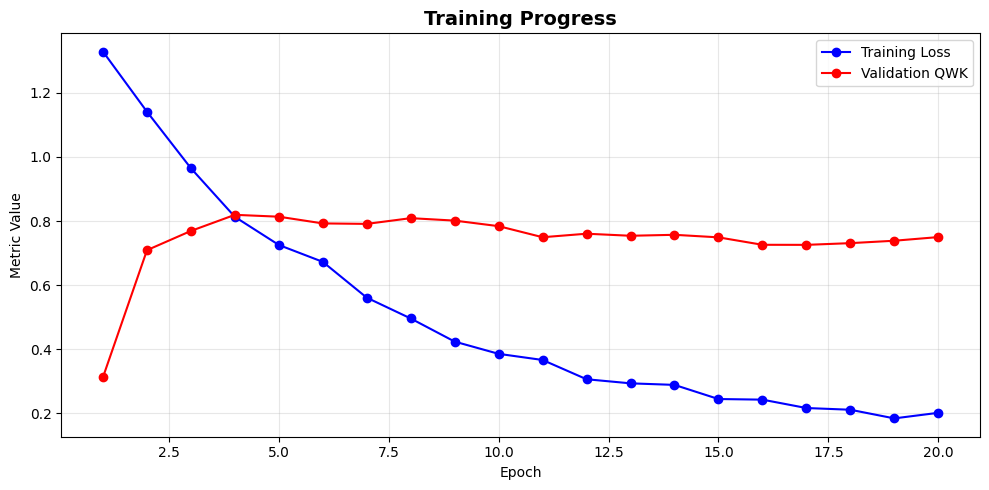


✅ Overall QWK Score on Validation: 0.7498


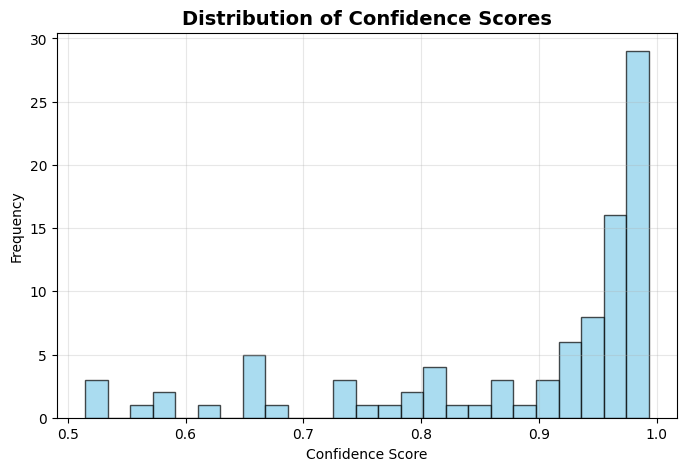


Text: Operating system manages all resources efficiently.
Predicted Score: 1, Confidence: 0.993

Text: An OS handles memory, process and file management.
Predicted Score: 1, Confidence: 0.987

Text: Operating system acts as an interface between hardware and user.
Predicted Score: 1, Confidence: 0.992


In [4]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import cohen_kappa_score
import matplotlib.pyplot as plt
from torch.nn.functional import softmax
import warnings
warnings.filterwarnings('ignore')

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ========================
#  QWK METRIC
# ========================
def quadratic_weighted_kappa(y_true, y_pred, labels=None):
    """Calculate Quadratic Weighted Kappa (QWK) score"""
    return cohen_kappa_score(y_true, y_pred, labels=labels, weights='quadratic')


# ========================
#  DATASET
# ========================
class EssayDataset(Dataset):
    def __init__(self, texts, scores, tokenizer, max_length=512):
        self.texts = texts
        self.scores = scores
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        score = self.scores[idx]

        encoding = self.tokenizer.encode_plus(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_attention_mask=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(score, dtype=torch.long)
        }


# ========================
#  TRAINING LOOP
# ========================
def train_model(model, train_loader, val_loader, num_epochs=10, learning_rate=2e-5):
    optimizer = AdamW(model.parameters(), lr=learning_rate)
    criterion = nn.CrossEntropyLoss()

    best_qwk = 0
    train_losses, val_qwk_scores, epochs_list = [], [], []

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0

        for batch in train_loader:
            optimizer.zero_grad()
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # ===== Validation =====
        model.eval()
        val_predictions, val_true_labels = [], []
        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)

                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                predictions = torch.argmax(outputs.logits, dim=-1)

                val_predictions.extend(predictions.cpu().numpy())
                val_true_labels.extend(labels.cpu().numpy())

        # Compute QWK
        qwk_score = quadratic_weighted_kappa(val_true_labels, val_predictions)
        val_qwk_scores.append(qwk_score)
        epochs_list.append(epoch + 1)

        print(f"Epoch {epoch+1}/{num_epochs}:")
        print(f"  Training Loss: {avg_train_loss:.4f}")
        print(f"  Validation QWK: {qwk_score:.4f}")

        # Save best model
        if qwk_score > best_qwk:
            best_qwk = qwk_score
            torch.save(model.state_dict(), 'best_bert_model.pth')

    return best_qwk, train_losses, val_qwk_scores, epochs_list


# ========================
#  TRAINING PLOTS
# ========================
def plot_training_metrics(train_losses, val_qwk_scores, epochs_list):
    plt.figure(figsize=(10, 5))
    plt.plot(epochs_list, train_losses, 'b-o', label='Training Loss')
    plt.plot(epochs_list, val_qwk_scores, 'r-o', label='Validation QWK')
    plt.title("Training Progress", fontsize=14, fontweight="bold")
    plt.xlabel("Epoch")
    plt.ylabel("Metric Value")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


# ========================
#  PREDICTION WITH CONFIDENCE
# ========================
def predict_scores_with_confidence(model, tokenizer, texts):
    model.eval()
    predictions, confidence_scores, all_probabilities = [], [], []

    with torch.no_grad():
        for text in texts:
            encoding = tokenizer.encode_plus(
                str(text),
                truncation=True,
                padding='max_length',
                max_length=512,
                return_attention_mask=True,
                return_tensors='pt'
            )

            input_ids = encoding['input_ids'].to(device)
            attention_mask = encoding['attention_mask'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)

            probs = softmax(outputs.logits, dim=-1)
            pred = torch.argmax(probs, dim=-1)
            conf = torch.max(probs).item()

            predictions.append(pred.cpu().numpy()[0] + 1)
            confidence_scores.append(conf)
            all_probabilities.append(probs.cpu().numpy()[0])

    return predictions, confidence_scores, all_probabilities


# ========================
#  VALIDATION CONFIDENCE ANALYSIS (QWK ONLY)
# ========================
def get_validation_confidence_scores(model, val_loader):
    model.eval()
    preds, confs, labels = [], [], []

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            y = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            probs = softmax(outputs.logits, dim=-1)
            pred = torch.argmax(probs, dim=-1)
            conf = torch.max(probs, dim=-1)[0]

            preds.extend(pred.cpu().numpy())
            confs.extend(conf.cpu().numpy())
            labels.extend(y.cpu().numpy())

    qwk = quadratic_weighted_kappa(labels, preds)
    print(f"\n✅ Overall QWK Score on Validation: {qwk:.4f}")
    return preds, confs, labels


def plot_confidence_distribution(confidence_scores):
    plt.figure(figsize=(8, 5))
    plt.hist(confidence_scores, bins=25, color='skyblue', edgecolor='black', alpha=0.7)
    plt.title("Distribution of Confidence Scores", fontsize=14, fontweight="bold")
    plt.xlabel("Confidence Score")
    plt.ylabel("Frequency")
    plt.grid(alpha=0.3)
    plt.show()


# ========================
#  MAIN FUNCTION
# ========================
def main():
    # Assuming 'd' DataFrame already exists
    df_id1 = d[d['iD'] == 4].copy()
    df_id1['avg_score'] = ((df_id1['Reviewer-1'] + df_id1['Reviewer-2']) / 2).round().astype(int)
    df_id1 = df_id1[df_id1['avg_score'].between(1, 5)]

    print("Original score distribution:")
    print(df_id1['avg_score'].value_counts().sort_index())

    texts = df_id1['Response'].values
    scores = df_id1['avg_score'].values
    scores_encoded = scores - 1
    num_classes = 5

    print(f"\nSamples: {len(texts)}, Classes: {num_classes}")

    X_train, X_val, y_train, y_val = train_test_split(
        texts, scores_encoded, test_size=0.2, random_state=42, stratify=scores_encoded
    )

    tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
    model = BertForSequenceClassification.from_pretrained(
        'bert-base-uncased', num_labels=num_classes
    ).to(device)

    train_dataset = EssayDataset(X_train, y_train, tokenizer)
    val_dataset = EssayDataset(X_val, y_val, tokenizer)
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

    print("\n🚀 Starting training...")
    best_qwk, train_losses, val_qwk_scores, epochs_list = train_model(
        model, train_loader, val_loader, num_epochs=20
    )

    print(f"\n🏆 Best Validation QWK: {best_qwk:.4f}")
    plot_training_metrics(train_losses, val_qwk_scores, epochs_list)

    return model, tokenizer, val_loader


# ========================
#  EXECUTION
# ========================
if __name__ == "__main__":
    model, tokenizer, val_loader = main()

    preds, confs, labels = get_validation_confidence_scores(model, val_loader)
    plot_confidence_distribution(confs)

    # Example sample predictions
    sample_texts = [
        "Operating system manages all resources efficiently.",
        "An OS handles memory, process and file management.",
        "Operating system acts as an interface between hardware and user."
    ]
    preds, confs, probs = predict_scores_with_confidence(model, tokenizer, sample_texts)
    for t, p, c in zip(sample_texts, preds, confs):
        print(f"\nText: {t}\nPredicted Score: {p}, Confidence: {c:.3f}")


id==5

2025-10-24 15:58:34.978291: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1761321515.204401      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761321515.271509      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Using device: cuda
Original score distribution:
avg_score
1    146
2    179
3     95
4      4
5      7
Name: count, dtype: int64

Samples: 431, Classes: 5


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



🚀 Starting training...
Epoch 1/10:
  Training Loss: 1.0575
  Validation QWK: 0.7599
Epoch 2/10:
  Training Loss: 0.7337
  Validation QWK: 0.8143
Epoch 3/10:
  Training Loss: 0.5737
  Validation QWK: 0.8148
Epoch 4/10:
  Training Loss: 0.4477
  Validation QWK: 0.7896
Epoch 5/10:
  Training Loss: 0.3677
  Validation QWK: 0.8113
Epoch 6/10:
  Training Loss: 0.3690
  Validation QWK: 0.8105
Epoch 7/10:
  Training Loss: 0.3130
  Validation QWK: 0.8289
Epoch 8/10:
  Training Loss: 0.2953
  Validation QWK: 0.7369
Epoch 9/10:
  Training Loss: 0.3241
  Validation QWK: 0.8102
Epoch 10/10:
  Training Loss: 0.2541
  Validation QWK: 0.8099

🏆 Best Validation QWK: 0.8289


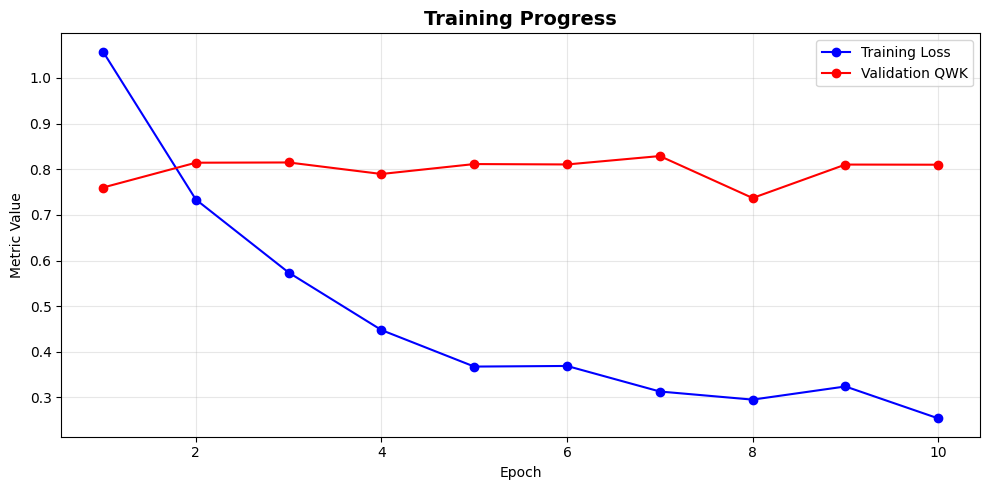


✅ Overall QWK Score on Validation: 0.8099


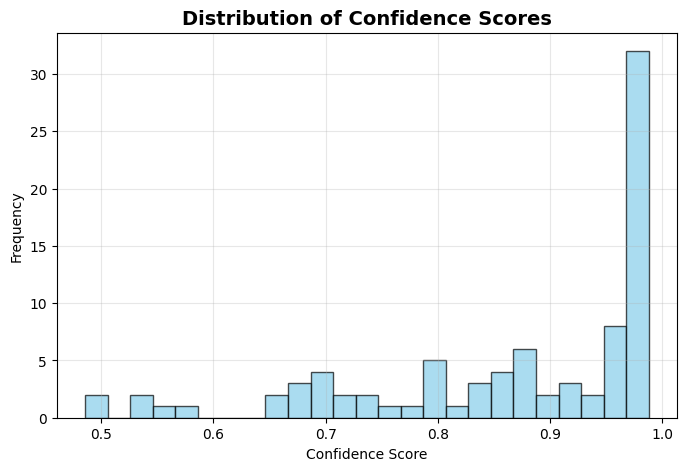


Text: Operating system manages all resources efficiently.
Predicted Score: 1, Confidence: 0.977

Text: An OS handles memory, process and file management.
Predicted Score: 1, Confidence: 0.981

Text: Operating system acts as an interface between hardware and user.
Predicted Score: 1, Confidence: 0.977


In [3]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import cohen_kappa_score
import matplotlib.pyplot as plt
from torch.nn.functional import softmax
import warnings
warnings.filterwarnings('ignore')

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ========================
#  QWK METRIC
# ========================
def quadratic_weighted_kappa(y_true, y_pred, labels=None):
    """Calculate Quadratic Weighted Kappa (QWK) score"""
    return cohen_kappa_score(y_true, y_pred, labels=labels, weights='quadratic')


# ========================
#  DATASET
# ========================
class EssayDataset(Dataset):
    def __init__(self, texts, scores, tokenizer, max_length=512):
        self.texts = texts
        self.scores = scores
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        score = self.scores[idx]

        encoding = self.tokenizer.encode_plus(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_attention_mask=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(score, dtype=torch.long)
        }


# ========================
#  TRAINING LOOP
# ========================
def train_model(model, train_loader, val_loader, num_epochs=20, learning_rate=2e-5):
    optimizer = AdamW(model.parameters(), lr=learning_rate)
    criterion = nn.CrossEntropyLoss()

    best_qwk = 0
    train_losses, val_qwk_scores, epochs_list = [], [], []

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0

        for batch in train_loader:
            optimizer.zero_grad()
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # ===== Validation =====
        model.eval()
        val_predictions, val_true_labels = [], []
        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)

                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                predictions = torch.argmax(outputs.logits, dim=-1)

                val_predictions.extend(predictions.cpu().numpy())
                val_true_labels.extend(labels.cpu().numpy())

        # Compute QWK
        qwk_score = quadratic_weighted_kappa(val_true_labels, val_predictions)
        val_qwk_scores.append(qwk_score)
        epochs_list.append(epoch + 1)

        print(f"Epoch {epoch+1}/{num_epochs}:")
        print(f"  Training Loss: {avg_train_loss:.4f}")
        print(f"  Validation QWK: {qwk_score:.4f}")

        # Save best model
        if qwk_score > best_qwk:
            best_qwk = qwk_score
            torch.save(model.state_dict(), 'best_bert_model.pth')

    return best_qwk, train_losses, val_qwk_scores, epochs_list


# ========================
#  TRAINING PLOTS
# ========================
def plot_training_metrics(train_losses, val_qwk_scores, epochs_list):
    plt.figure(figsize=(10, 5))
    plt.plot(epochs_list, train_losses, 'b-o', label='Training Loss')
    plt.plot(epochs_list, val_qwk_scores, 'r-o', label='Validation QWK')
    plt.title("Training Progress", fontsize=14, fontweight="bold")
    plt.xlabel("Epoch")
    plt.ylabel("Metric Value")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


# ========================
#  PREDICTION WITH CONFIDENCE
# ========================
def predict_scores_with_confidence(model, tokenizer, texts):
    model.eval()
    predictions, confidence_scores, all_probabilities = [], [], []

    with torch.no_grad():
        for text in texts:
            encoding = tokenizer.encode_plus(
                str(text),
                truncation=True,
                padding='max_length',
                max_length=512,
                return_attention_mask=True,
                return_tensors='pt'
            )

            input_ids = encoding['input_ids'].to(device)
            attention_mask = encoding['attention_mask'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)

            probs = softmax(outputs.logits, dim=-1)
            pred = torch.argmax(probs, dim=-1)
            conf = torch.max(probs).item()

            predictions.append(pred.cpu().numpy()[0] + 1)
            confidence_scores.append(conf)
            all_probabilities.append(probs.cpu().numpy()[0])

    return predictions, confidence_scores, all_probabilities


# ========================
#  VALIDATION CONFIDENCE ANALYSIS (QWK ONLY)
# ========================
def get_validation_confidence_scores(model, val_loader):
    model.eval()
    preds, confs, labels = [], [], []

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            y = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            probs = softmax(outputs.logits, dim=-1)
            pred = torch.argmax(probs, dim=-1)
            conf = torch.max(probs, dim=-1)[0]

            preds.extend(pred.cpu().numpy())
            confs.extend(conf.cpu().numpy())
            labels.extend(y.cpu().numpy())

    qwk = quadratic_weighted_kappa(labels, preds)
    print(f"\n✅ Overall QWK Score on Validation: {qwk:.4f}")
    return preds, confs, labels


def plot_confidence_distribution(confidence_scores):
    plt.figure(figsize=(8, 5))
    plt.hist(confidence_scores, bins=25, color='skyblue', edgecolor='black', alpha=0.7)
    plt.title("Distribution of Confidence Scores", fontsize=14, fontweight="bold")
    plt.xlabel("Confidence Score")
    plt.ylabel("Frequency")
    plt.grid(alpha=0.3)
    plt.show()


# ========================
#  MAIN FUNCTION
# ========================
def main():
    # Assuming 'd' DataFrame already exists
    df_id1 = d[d['iD'] == 5].copy()
    df_id1['avg_score'] = ((df_id1['Reviewer-1'] + df_id1['Reviewer-2']) / 2).round().astype(int)
    df_id1 = df_id1[df_id1['avg_score'].between(1, 5)]

    print("Original score distribution:")
    print(df_id1['avg_score'].value_counts().sort_index())

    texts = df_id1['Response'].values
    scores = df_id1['avg_score'].values
    scores_encoded = scores - 1
    num_classes = 5

    print(f"\nSamples: {len(texts)}, Classes: {num_classes}")

    X_train, X_val, y_train, y_val = train_test_split(
        texts, scores_encoded, test_size=0.2, random_state=42, stratify=scores_encoded
    )

    tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
    model = BertForSequenceClassification.from_pretrained(
        'bert-base-uncased', num_labels=num_classes
    ).to(device)

    train_dataset = EssayDataset(X_train, y_train, tokenizer)
    val_dataset = EssayDataset(X_val, y_val, tokenizer)
    train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

    print("\n🚀 Starting training...")
    best_qwk, train_losses, val_qwk_scores, epochs_list = train_model(
        model, train_loader, val_loader, num_epochs=10
    )

    print(f"\n🏆 Best Validation QWK: {best_qwk:.4f}")
    plot_training_metrics(train_losses, val_qwk_scores, epochs_list)

    return model, tokenizer, val_loader


# ========================
#  EXECUTION
# ========================
if __name__ == "__main__":
    model, tokenizer, val_loader = main()

    preds, confs, labels = get_validation_confidence_scores(model, val_loader)
    plot_confidence_distribution(confs)

    # Example sample predictions
    sample_texts = [
        "Operating system manages all resources efficiently.",
        "An OS handles memory, process and file management.",
        "Operating system acts as an interface between hardware and user."
    ]
    preds, confs, probs = predict_scores_with_confidence(model, tokenizer, sample_texts)
    for t, p, c in zip(sample_texts, preds, confs):
        print(f"\nText: {t}\nPredicted Score: {p}, Confidence: {c:.3f}")


DPR 

In [1]:
pip install sentence-transformers faiss-cpu


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 63.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 81.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 64.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 2.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 10.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 17.6 MB/s eta 0:00:0000:0100:01
  Attempting uni

In [ ]:
# ========================
#  INSTALL (run once)
# ========================
# !pip install sentence-transformers faiss-cpu transformers torch scikit-learn matplotlib

# ========================
#  IMPORTS
# ========================
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import cohen_kappa_score
import matplotlib.pyplot as plt
from torch.nn.functional import softmax
import warnings
warnings.filterwarnings('ignore')

from sentence_transformers import SentenceTransformer
import faiss

# ========================
#  DEVICE
# ========================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ========================
#  QWK METRIC
# ========================
def quadratic_weighted_kappa(y_true, y_pred, labels=None):
    return cohen_kappa_score(y_true, y_pred, labels=labels, weights='quadratic')

# ===================================================
#  DPR RETRIEVER (KEY ADDITION FOR RAG)
# ===================================================
class DPRRetriever:
    def __init__(self, corpus_texts):
        print("\n🔍 Building DPR index...")
        self.encoder = SentenceTransformer(
            "facebook-dpr-ctx_encoder-single-nq-base"
        )

        self.texts = list(corpus_texts)

        embeddings = self.encoder.encode(self.texts, show_progress_bar=True)
        embeddings = np.array(embeddings).astype("float32")

        dim = embeddings.shape[1]
        self.index = faiss.IndexFlatL2(dim)
        self.index.add(embeddings)

        self.embeddings = embeddings
        print(f"✅ DPR index built with {len(self.texts)} documents.")

    def retrieve(self, query, k=2):
        query_emb = self.encoder.encode([query]).astype("float32")
        distances, indices = self.index.search(query_emb, k)
        retrieved_texts = [self.texts[i] for i in indices[0]]
        return retrieved_texts

# ===================================================
#  DATASET WITH DPR AUGMENTATION
# ===================================================
class EssayDataset(Dataset):
    def __init__(self, texts, scores, tokenizer, retriever=None, max_length=512):
        self.texts = texts
        self.scores = scores
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.retriever = retriever

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        score = self.scores[idx]

        # ======= DPR AUGMENTATION =======
        if self.retriever:
            retrieved = self.retriever.retrieve(text, k=2)
            augmented_text = text + " [SEP] " + " ".join(retrieved)
        else:
            augmented_text = text
        # ================================

        encoding = self.tokenizer.encode_plus(
            augmented_text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_attention_mask=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(score, dtype=torch.long)
        }

# ===================================================
#  TRAINING LOOP (UNCHANGED LOGIC)
# ===================================================
def train_model(model, train_loader, val_loader, num_epochs=10, learning_rate=2e-5):
    optimizer = AdamW(model.parameters(), lr=learning_rate)

    best_qwk = 0
    train_losses, val_qwk_scores, epochs_list = [], [], []

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0

        for batch in train_loader:
            optimizer.zero_grad()

            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # ===== Validation =====
        model.eval()
        val_predictions, val_true_labels = [], []

        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)

                outputs = model(
                    input_ids=input_ids,
                    attention_mask=attention_mask
                )

                predictions = torch.argmax(outputs.logits, dim=-1)
                val_predictions.extend(predictions.cpu().numpy())
                val_true_labels.extend(labels.cpu().numpy())

        qwk_score = quadratic_weighted_kappa(
            val_true_labels, val_predictions
        )

        val_qwk_scores.append(qwk_score)
        epochs_list.append(epoch + 1)

        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print(f"Training Loss: {avg_train_loss:.4f}")
        print(f"Validation QWK: {qwk_score:.4f}")

        if qwk_score > best_qwk:
            best_qwk = qwk_score
            torch.save(model.state_dict(), "best_bert_dpr_model.pth")

    return best_qwk, train_losses, val_qwk_scores, epochs_list

# ===================================================
#  PLOTS
# ===================================================
def plot_training_metrics(train_losses, val_qwk_scores, epochs_list):
    plt.figure(figsize=(10, 5))
    plt.plot(epochs_list, train_losses, label='Training Loss')
    plt.plot(epochs_list, val_qwk_scores, label='Validation QWK')
    plt.title("Training Progress (BERT + DPR)")
    plt.xlabel("Epoch")
    plt.ylabel("Metric")
    plt.grid(True)
    plt.legend()
    plt.show()

# ===================================================
#  CONFIDENCE ANALYSIS
# ===================================================
def get_validation_confidence_scores(model, val_loader):
    model.eval()
    preds, confs, labels = [], [], []

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            y = batch['labels'].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            probs = softmax(outputs.logits, dim=-1)
            pred = torch.argmax(probs, dim=-1)
            conf = torch.max(probs, dim=-1)[0]

            preds.extend(pred.cpu().numpy())
            confs.extend(conf.cpu().numpy())
            labels.extend(y.cpu().numpy())

    qwk = quadratic_weighted_kappa(labels, preds)
    print(f"\n✅ Overall Validation QWK: {qwk:.4f}")
    return preds, confs, labels

def plot_confidence_distribution(confidence_scores):
    plt.figure(figsize=(8, 5))
    plt.hist(confidence_scores, bins=25)
    plt.title("Confidence Distribution")
    plt.xlabel("Confidence")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.show()

# ===================================================
#  MAIN PIPELINE (YOUR DATA FORMAT)
# ===================================================
def main():
    # ======= YOUR DATAFRAME MUST EXIST AS 'd' =======
    df_id1 = d[d['iD'] == 4].copy()

    df_id1['avg_score'] = (
        (df_id1['Reviewer-1'] + df_id1['Reviewer-2']) / 2
    ).round().astype(int)

    df_id1 = df_id1[df_id1['avg_score'].between(1, 5)]

    print("\nOriginal score distribution:")
    print(df_id1['avg_score'].value_counts().sort_index())

    texts = df_id1['Response'].values
    scores = df_id1['avg_score'].values
    scores_encoded = scores - 1
    num_classes = 5

    print(f"\nSamples: {len(texts)}, Classes: {num_classes}")

    X_train, X_val, y_train, y_val = train_test_split(
        texts,
        scores_encoded,
        test_size=0.2,
        random_state=42,
        stratify=scores_encoded
    )

    # ======= BUILD DPR KNOWLEDGE BASE =======
    retriever = DPRRetriever(texts)

    tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

    model = BertForSequenceClassification.from_pretrained(
        'bert-base-uncased',
        num_labels=num_classes
    ).to(device)

    train_dataset = EssayDataset(
        X_train, y_train, tokenizer, retriever
    )

    val_dataset = EssayDataset(
        X_val, y_val, tokenizer, retriever
    )

    train_loader = DataLoader(
        train_dataset, batch_size=16, shuffle=True
    )

    val_loader = DataLoader(
        val_dataset, batch_size=16, shuffle=False
    )

    print("\n🚀 Starting BERT + DPR Training...\n")

    best_qwk, train_losses, val_qwk_scores, epochs_list = train_model(
        model,
        train_loader,
        val_loader,
        num_epochs=10
    )

    print(f"\n🏆 Best Validation QWK: {best_qwk:.4f}")
    plot_training_metrics(train_losses, val_qwk_scores, epochs_list)

    return model, tokenizer, val_loader

# ===================================================
#  RUN
# ===================================================
if __name__ == "__main__":
    model, tokenizer, val_loader = main()

    preds, confs, labels = get_validation_confidence_scores(
        model, val_loader
    )

    plot_confidence_distribution(confs)

    # Sample prediction
    sample_texts = [
        "Operating system manages all resources efficiently.",
        "An OS handles memory, process and file management.",
        "Operating system acts as an interface between hardware and user."
    ]

    print("\n=== Sample Predictions ===")
    for t in sample_texts:
        encoding = tokenizer.encode_plus(
            t,
            truncation=True,
            padding='max_length',
            max_length=512,
            return_attention_mask=True,
            return_tensors='pt'
        )

        with torch.no_grad():
            outputs = model(
                input_ids=encoding['input_ids'].to(device),
                attention_mask=encoding['attention_mask'].to(device)
            )

        probs = softmax(outputs.logits, dim=-1)
        pred = torch.argmax(probs, dim=-1).item() + 1
        conf = torch.max(probs).item()

        print(f"\nText: {t}")
        print(f"Predicted Score: {pred}, Confidence: {conf:.3f}")


Using device: cuda

Original score distribution:
avg_score
1    180
2    145
3    121
4      7
5      3
Name: count, dtype: int64

Samples: 456, Classes: 5

🔍 Building DPR index...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/212 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]